In [ ]:
import os

data_path = os.path.curdir

import pandas as pd

data = pd.read_csv(os.path.join(data_path, "V8.csv")) #pandas объект dataframe

In [ ]:
data.head() # первые 5 строк

,Unnamed: 0.1,Unnamed: 0,cost_price,profit_markup,depth_of_tree,sales_commission,profit
0,0,1,3500.0,2,21,1000,-16500
1,1,2,3500.0,2,26,1000,-21500
2,2,3,NaN,2,23,1000,-18500
3,3,4,NaN,3,12,1000,-4000
4,4,5,3500.0,2,12,1000,-7500


In [ ]:
data.shape # размерность набора данных

(500, 7)

In [ ]:
data.dtypes # типы атрибутов

,0
Unnamed: 0.1,int64
Unnamed: 0,int64
cost_price,float64
profit_markup,int64
depth_of_tree,int64
sales_commission,int64
profit,int64


In [ ]:
data.info() # число строк, количество ненулевых значений и типов атрибутов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0.1      500 non-null    int64  
 1   Unnamed: 0        500 non-null    int64  
 2   cost_price        244 non-null    float64
 3   profit_markup     500 non-null    int64  
 4   depth_of_tree     500 non-null    int64  
 5   sales_commission  500 non-null    int64  
 6   profit            500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [ ]:
data.describe() # сводка по числовым атрибутам

,Unnamed: 0.1,Unnamed: 0,cost_price,profit_markup,depth_of_tree,sales_commission,profit
count,500.000000,500.000000,244.0,500.000000,500.000000,500.0,500.000000
mean,249.500000,250.500000,3500.0,3.498000,15.896000,1000.0,-6153.000000
std,144.481833,144.481833,0.0,1.126292,8.095694,0.0,9080.528784
min,0.000000,1.000000,3500.0,2.000000,2.000000,1000.0,-25500.000000
25%,124.750000,125.750000,3500.0,3.000000,9.000000,1000.0,-12500.000000
50%,249.500000,250.500000,3500.0,3.000000,16.000000,1000.0,-6500.000000
75%,374.250000,375.250000,3500.0,5.000000,23.000000,1000.0,500.000000
max,499.000000,500.000000,3500.0,5.000000,30.000000,1000.0,13000.000000


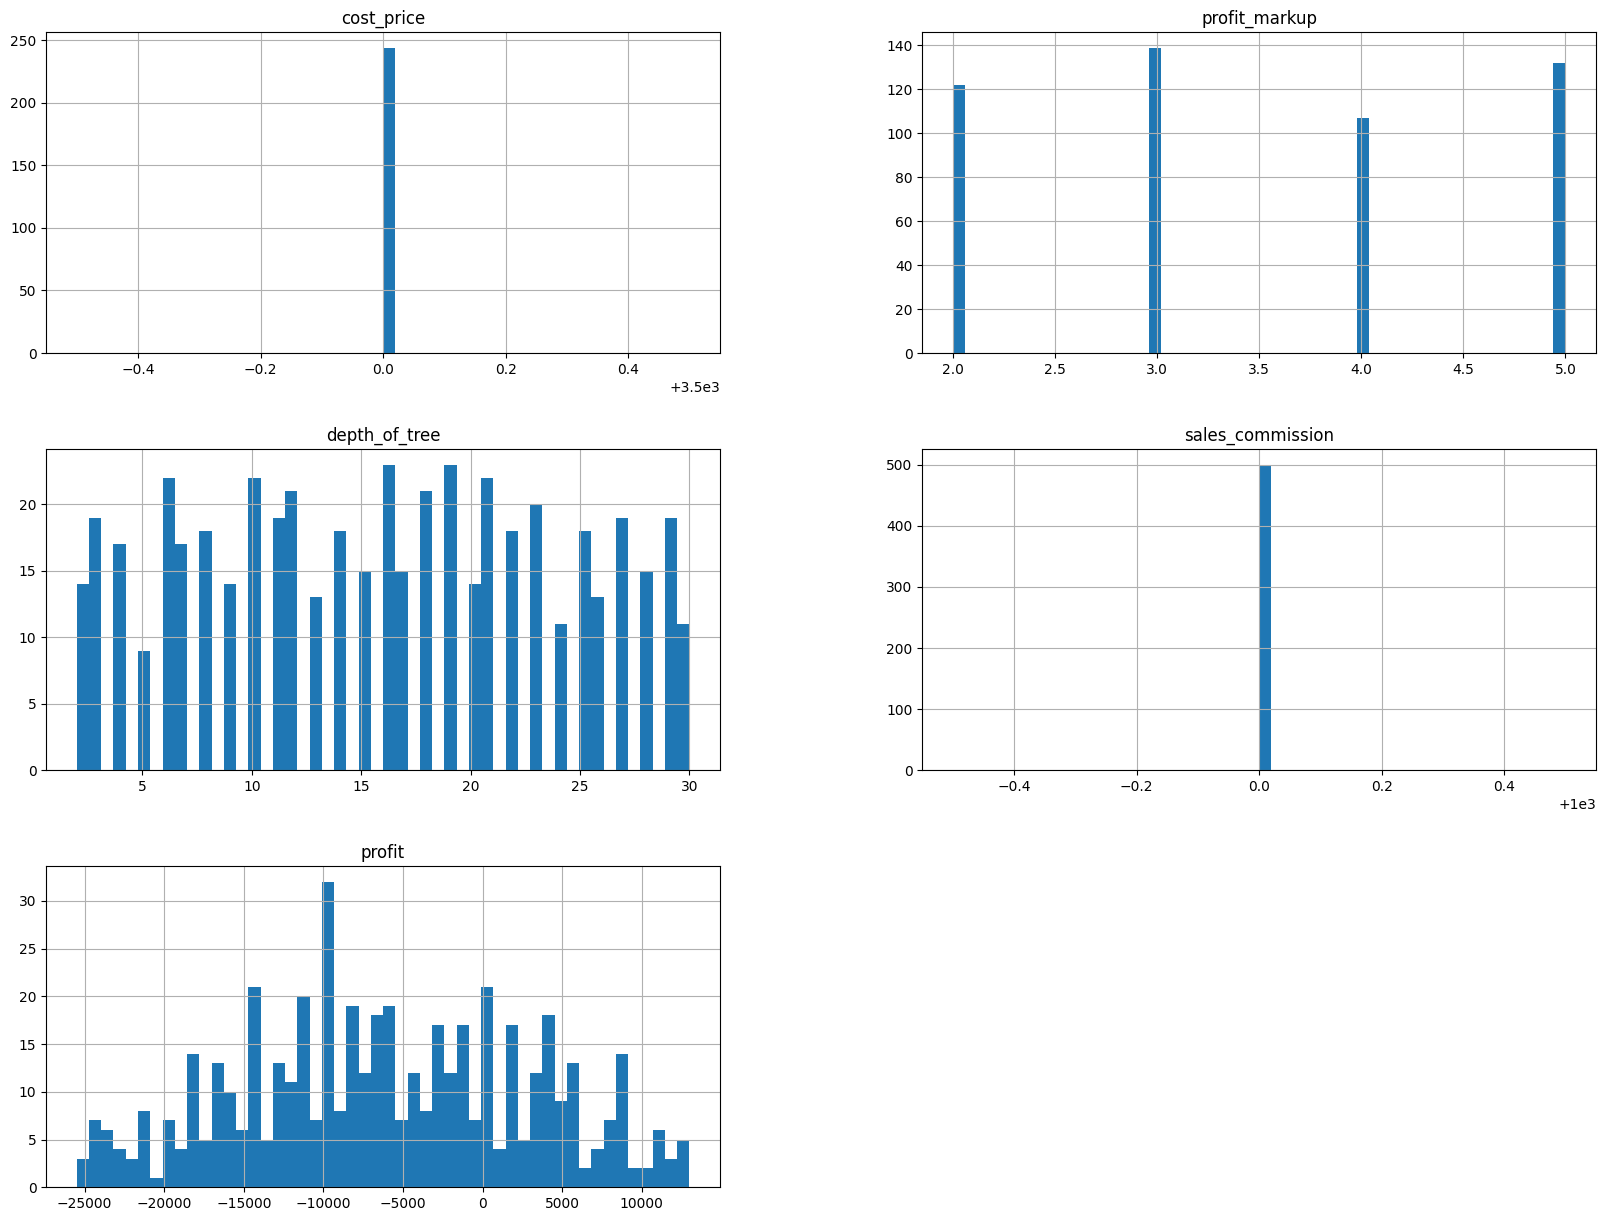

In [ ]:
# магическая команда для автоматического отображения
# визуализации при выполнении ячейки
# %matplotlib inline

import matplotlib.pyplot as plt

data[['cost_price', 'profit_markup', 'depth_of_tree', 'sales_commission', 'profit']].hist(bins=50, figsize=(20,15))
plt.show()

Графики плотности


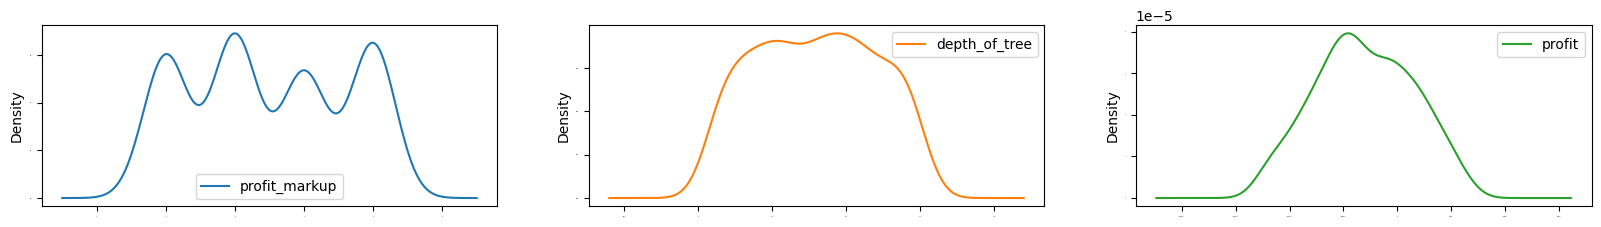

In [ ]:
data[['profit_markup', 'depth_of_tree', 'profit']].\
plot(kind='density', subplots=True, layout=(3,3), sharex=False, legend=True,\
     fontsize=1, figsize=(20,8))
plt.show()

<Axes: title={'center': 'correlation matrix'}>

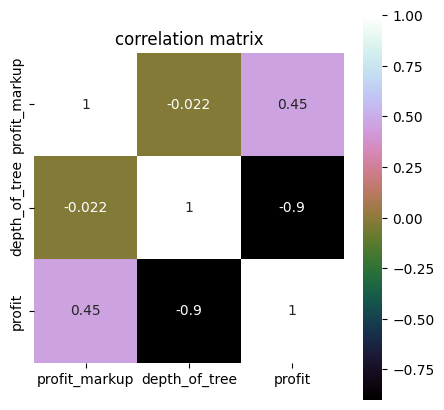

In [ ]:
#: график корреляционной матрицы

import seaborn as sns

correlation = data[['profit_markup', 'depth_of_tree', 'profit']].corr()
plt.figure(figsize=(5,5))
plt.title('correlation matrix')
sns.heatmap(correlation, vmax=1, square=True, annot=True, cmap='cubehelix')

array([[<Axes: xlabel='profit_markup', ylabel='profit_markup'>,
        <Axes: xlabel='depth_of_tree', ylabel='profit_markup'>,
        <Axes: xlabel='profit', ylabel='profit_markup'>],
       [<Axes: xlabel='profit_markup', ylabel='depth_of_tree'>,
        <Axes: xlabel='depth_of_tree', ylabel='depth_of_tree'>,
        <Axes: xlabel='profit', ylabel='depth_of_tree'>],
       [<Axes: xlabel='profit_markup', ylabel='profit'>,
        <Axes: xlabel='depth_of_tree', ylabel='profit'>,
        <Axes: xlabel='profit', ylabel='profit'>]], dtype=object)

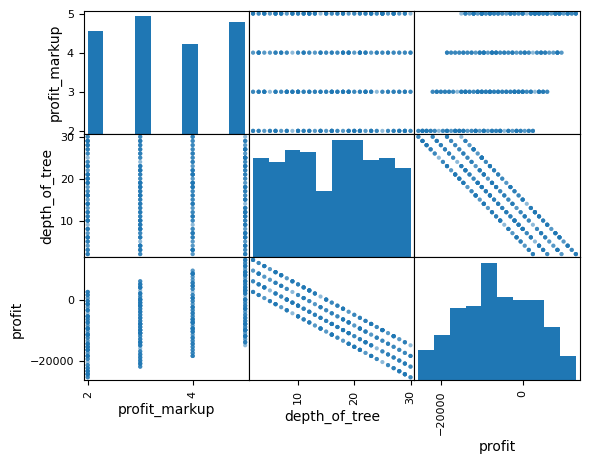

In [ ]:
# матрица диаграммы рассеяния

from pandas.plotting import scatter_matrix
scatter_matrix(data[['profit_markup', 'depth_of_tree', 'profit']])

creating new attributes

In [ ]:
data['profit_markup_per_depth'] = data['profit_markup']/data['depth_of_tree']


In [ ]:
# Стандартный коэф. корреляции

corr_matrix = data.corr()
corr_matrix

,Unnamed: 0.1,Unnamed: 0,cost_price,profit_markup,depth_of_tree,sales_commission,profit,profit_markup_per_depth
Unnamed: 0.1,1.000000,1.000000,NaN,-0.013048,-0.011018,NaN,0.004159,-0.005987
Unnamed: 0,1.000000,1.000000,NaN,-0.013048,-0.011018,NaN,0.004159,-0.005987
cost_price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
profit_markup,-0.013048,-0.013048,NaN,1.000000,-0.021562,NaN,0.453341,0.318411
depth_of_tree,-0.011018,-0.011018,NaN,-0.021562,1.000000,NaN,-0.900905,-0.692209
sales_commission,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
profit,0.004159,0.004159,NaN,0.453341,-0.900905,NaN,1.000000,0.755363
profit_markup_per_depth,-0.005987,-0.005987,NaN,0.318411,-0.692209,NaN,0.755363,1.000000


In [ ]:
corr_matrix["profit"].sort_values(ascending=False)

,profit
profit,1.000000
profit_markup_per_depth,0.755363
profit_markup,0.453341
Unnamed: 0.1,0.004159
Unnamed: 0,0.004159
depth_of_tree,-0.900905
cost_price,NaN
sales_commission,NaN


array([[<Axes: xlabel='profit_markup', ylabel='profit_markup'>,
        <Axes: xlabel='depth_of_tree', ylabel='profit_markup'>,
        <Axes: xlabel='profit', ylabel='profit_markup'>,
        <Axes: xlabel='profit_markup_per_depth', ylabel='profit_markup'>],
       [<Axes: xlabel='profit_markup', ylabel='depth_of_tree'>,
        <Axes: xlabel='depth_of_tree', ylabel='depth_of_tree'>,
        <Axes: xlabel='profit', ylabel='depth_of_tree'>,
        <Axes: xlabel='profit_markup_per_depth', ylabel='depth_of_tree'>],
       [<Axes: xlabel='profit_markup', ylabel='profit'>,
        <Axes: xlabel='depth_of_tree', ylabel='profit'>,
        <Axes: xlabel='profit', ylabel='profit'>,
        <Axes: xlabel='profit_markup_per_depth', ylabel='profit'>],
       [<Axes: xlabel='profit_markup', ylabel='profit_markup_per_depth'>,
        <Axes: xlabel='depth_of_tree', ylabel='profit_markup_per_depth'>,
        <Axes: xlabel='profit', ylabel='profit_markup_per_depth'>,
        <Axes: xlabel='profit_mar

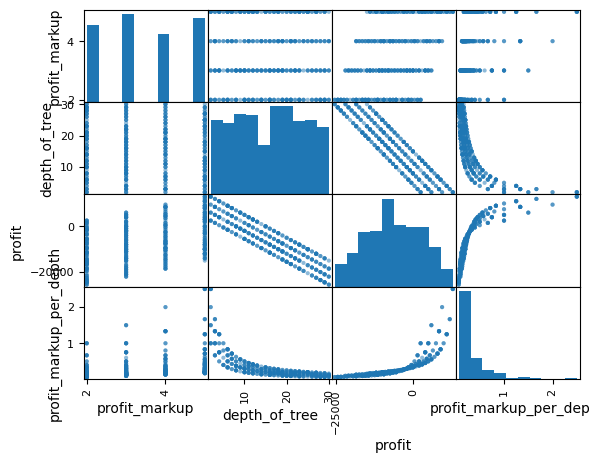

In [ ]:
# матрица диаграммы рассеяния

from pandas.plotting import scatter_matrix
scatter_matrix(data[['profit_markup', 'depth_of_tree', 'profit', 'profit_markup_per_depth']])

In [ ]:
data_changed = data.drop(["Unnamed: 0", "Unnamed: 0.1", "cost_price", "sales_commission",], axis=1, inplace=False)
data_changed = data_changed[['profit_markup', 'depth_of_tree', 'profit']]
data_changed

,profit_markup,depth_of_tree,profit
0,2,21,-16500
1,2,26,-21500
2,2,23,-18500
3,3,12,-4000
4,2,12,-7500
...,...,...,...
495,5,12,3000
496,3,8,0
497,2,10,-5500
498,4,21,-9500


In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

data_X = data_changed.iloc[:,:3]
data_Y = data_changed['profit']

beastfeatures = SelectKBest(f_regression, k=3)
fit = beastfeatures.fit(data_X, data_Y)
dfscores = pd.DataFrame(fit.scores_)
dfcolumns = pd.DataFrame(data_X.columns)
featureScores = pd.concat([dfcolumns, dfscores],axis=1)
featureScores

,0,0
0,profit_markup,1.288237e+02
1,depth_of_tree,2.145721e+03
2,profit,-1.121396e+18


In [ ]:
from sklearn.preprocessing import Normalizer
scaler = Normalizer().fit(data_changed)
Normalized_data_changed = pd.DataFrame(scaler.fit_transform(data_changed))
Normalized_data_changed

,0,1,2
0,0.000121,0.001273,-0.999999
1,0.000093,0.001209,-0.999999
2,0.000108,0.001243,-0.999999
3,0.000750,0.003000,-0.999995
4,0.000267,0.001600,-0.999999
...,...,...,...
495,0.001667,0.004000,0.999991
496,0.351123,0.936329,0.000000
497,0.000364,0.001818,-0.999998
498,0.000421,0.002211,-0.999997


Разделение на обучающую, проверочную и тестовую выборки данных для **преобразованного построенного набора данных**

---



In [ ]:
ndc_X = Normalized_data_changed.iloc[:,:3]
ndc_Y = Normalized_data_changed.iloc[:,-1]

from sklearn.model_selection import train_test_split
test_size = 0.2
val_size = 0.25
seed = 7

ndc_X_train, ndc_X_test, ndc_Y_train, ndc_Y_test =\
train_test_split(ndc_X, ndc_Y, test_size=test_size, random_state=seed)

ndc_X_train, ndc_X_val, ndc_Y_train, ndc_Y_val =\
train_test_split(ndc_X_train,  ndc_Y_train, test_size = val_size, random_state=seed)

ndc_X_train

,0,1,2
167,0.001250,0.004750,-0.999988
380,0.000500,0.000500,1.000000
357,0.000625,0.002875,-0.999996
224,0.000833,0.001500,0.999999
102,0.000625,0.000875,0.999999
...,...,...,...
116,0.000211,0.001474,-0.999999
263,0.000121,0.001273,-0.999999
298,0.000176,0.001471,-0.999999
255,0.001667,0.006000,-0.999981


Разделение на обучающую, проверочную и тестовую выборки данных для **построенного набора данных**

---

In [ ]:
dc_X = data_changed.iloc[:,:3]
dc_Y = data_changed['profit']

dc_X_train, dc_X_test, dc_Y_train, dc_Y_test =\
train_test_split(dc_X, dc_Y, test_size=test_size, random_state=seed)

dc_X_train, dc_X_val, dc_Y_train, dc_Y_val =\
train_test_split(dc_X_train,  dc_Y_train, test_size = val_size, random_state=seed)

dc_X_train

,profit_markup,depth_of_tree,profit
167,5,19,-4000
380,5,5,10000
357,5,23,-8000
224,5,9,6000
102,5,7,8000
...,...,...,...
116,2,14,-9500
263,2,21,-16500
298,3,25,-17000
255,5,18,-3000


Разделение на обучающую, проверочную и тестовую выборки данных для **исходного набора данных**

---

In [ ]:
data['cost_price'] = data['cost_price'].fillna(3500)

d_X = data.iloc[:,:6]
d_Y = data['profit']

d_X_train, d_X_test, d_Y_train, d_Y_test =\
train_test_split(d_X, d_Y, test_size=test_size, random_state=seed)

d_X_train, d_X_val, d_Y_train, d_Y_val =\
train_test_split(d_X_train,  d_Y_train, test_size = val_size, random_state=seed)

d_X_train

,Unnamed: 0.1,Unnamed: 0,cost_price,profit_markup,depth_of_tree,sales_commission
167,167,168,3500.0,5,19,1000
380,380,381,3500.0,5,5,1000
357,357,358,3500.0,5,23,1000
224,224,225,3500.0,5,9,1000
102,102,103,3500.0,5,7,1000
...,...,...,...,...,...,...
116,116,117,3500.0,2,14,1000
263,263,264,3500.0,2,21,1000
298,298,299,3500.0,3,25,1000
255,255,256,3500.0,5,18,1000


Разделение на обучающую, проверочную и тестовую выборки данных для **преобразованного исходного набора данных**

---

In [ ]:

scaler = Normalizer().fit(data)
Normalized_data = pd.DataFrame(scaler.fit_transform(data))
Normalized_data

,0,1,2,3,4,5,6,7
0,0.000000,0.000059,0.207140,0.000118,0.001243,0.059183,-0.976519,0.000006
1,0.000046,0.000092,0.160506,0.000092,0.001192,0.045859,-0.985968,0.000004
2,0.000106,0.000159,0.185630,0.000106,0.001220,0.053037,-0.981187,0.000005
3,0.000555,0.000740,0.647148,0.000555,0.002219,0.184900,-0.739598,0.000046
4,0.000480,0.000600,0.419832,0.000240,0.001439,0.119952,-0.899639,0.000020
...,...,...,...,...,...,...,...,...
495,0.103800,0.104010,0.733941,0.001048,0.002516,0.209697,0.629092,0.000087
496,0.133795,0.134065,0.944117,0.000809,0.002158,0.269748,0.000000,0.000101
497,0.074930,0.075080,0.527674,0.000302,0.001508,0.150764,-0.829202,0.000030
498,0.048834,0.048932,0.343207,0.000392,0.002059,0.098059,-0.931563,0.000019


In [ ]:
nd_X = Normalized_data.iloc[:,:6]
nd_Y = Normalized_data.iloc[:,-1]

nd_X_train, nd_X_test, nd_Y_train, nd_Y_test =\
train_test_split(nd_X, nd_Y, test_size=test_size, random_state=seed)

nd_X_train, nd_X_val, nd_Y_train, nd_Y_val =\
train_test_split(nd_X_train,  nd_Y_train, test_size = val_size, random_state=seed)

nd_X_train

,0,1,2,3,4,5
167,0.030849,0.031033,0.646526,0.000924,0.003510,0.184722
380,0.035662,0.035756,0.328469,0.000469,0.000469,0.093848
357,0.040551,0.040664,0.397557,0.000568,0.002613,0.113588
224,0.031886,0.032028,0.498219,0.000712,0.001281,0.142348
102,0.011604,0.011717,0.398162,0.000569,0.000796,0.113760
...,...,...,...,...,...,...
116,0.011401,0.011499,0.343986,0.000197,0.001376,0.098282
263,0.015561,0.015621,0.207090,0.000118,0.001243,0.059169
298,0.017136,0.017193,0.201260,0.000173,0.001438,0.057503
255,0.053902,0.054113,0.739825,0.001057,0.003805,0.211379


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, SimpleRNN
import numpy as np

def build_fully_connected_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(256, activation='relu'))  # Увеличиваем количество нейронов для большего потенциала обучения
    model.add(Dense(128, activation='relu'))  # Увеличиваем количество нейронов для большего потенциала обучения
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))   # Добавляем больше слоев для глубины
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model


def build_simple_rnn_model(input_shape):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(SimpleRNN(64, activation='tanh', return_sequences=True))  # Первый рекуррентный слой
    model.add(SimpleRNN(64, activation='tanh', return_sequences=True))  # Второй рекуррентный слой
    model.add(SimpleRNN(64, activation='tanh', return_sequences=True))  # 3 рекуррентный слой
    model.add(SimpleRNN(32, activation='tanh'))                         # Последний слой
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))                             # Добавляем больше Dense-слоев
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model





Обучение с преобразоваными нормализованными данными

In [ ]:
# Определяем размер входных данных для полносвязной модели
input_shape_fc = (ndc_X_train.shape[1],)
# Создание моделей с правильной формой входных данных
ndc_fc_model = build_fully_connected_model(input_shape_fc)

# Для рекуррентной модели можно использовать ту же форму, но с добавлением размерности
input_shape_rnn = (ndc_X_train.shape[1], 1)

ndc_rnn_model = build_simple_rnn_model(input_shape_rnn)

In [ ]:
# Преобразуем данные для рекуррентной модели
ndc_X_train_rnn = ndc_X_train.values.reshape((ndc_X_train.shape[0], ndc_X_train.shape[1], 1))
ndc_X_val_rnn = ndc_X_val.values.reshape((ndc_X_val.shape[0], ndc_X_val.shape[1], 1))

# Обучение рекуррентной модели
ndc_rnn_model.fit(ndc_X_train_rnn, ndc_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.7802
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1670
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0059     
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0032 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.4369e-04
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4729e-04 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1356e-04 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.5893e-05 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7620e-05
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.9255e-06 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0194e-05 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.3819e-06
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0228e-05
Epoch 15/100
10/10 ━━━

In [ ]:
# Преобразуем данные для полносвязной модели
ndc_X_train_fc = ndc_X_train.values
ndc_X_val_fc = ndc_X_val.values

# Обучение рекуррентной модели
ndc_fc_model.fit(ndc_X_train_fc, ndc_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.7313
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2002 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0681 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0167 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0047 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.0947e-04 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.4572e-04 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.3940e-05 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.7947e-05 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.1567e-05  
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7143e-06 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7609e-06 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9495e-07 
Epoch 15/100
10/10 ━━━━━━

Обучение с преобразоваными не нормализованными данными

In [ ]:
# Определяем размер входных данных для полносвязной модели
input_shape_fc = (dc_X_train.shape[1],)
# Создание моделей с правильной формой входных данных
dc_fc_model = build_fully_connected_model(input_shape_fc)

# Для рекуррентной модели можно использовать ту же форму, но с добавлением размерности
input_shape_rnn = (dc_X_train.shape[1], 1)
dc_rnn_model = build_simple_rnn_model(input_shape_rnn)

In [ ]:
# Преобразуем данные для рекуррентной модели
dc_X_train_rnn = dc_X_train.values.reshape((dc_X_train.shape[0], dc_X_train.shape[1], 1))
dc_X_val_rnn = dc_X_val.values.reshape((dc_X_val.shape[0], dc_X_val.shape[1], 1))

# Обучение рекуррентной модели
dc_rnn_model.fit(dc_X_train_rnn, dc_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 119244096.0000
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 115679664.0000
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 126259360.0000 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 109306992.0000 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 114899032.0000
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 120284944.0000
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 116222888.0000
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 115661536.0000
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 126890464.0000 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 119469384.0000
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 117694272.0000
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 118620048.0000 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 122047800.0000
Epoch 14/100
10/10 ━━━━━━━━━━━

In [ ]:
# Преобразуем данные для полносвязной модели
dc_X_train_fc = dc_X_train.values
dc_X_val_fc = dc_X_val.values

# Обучение рекуррентной модели
dc_fc_model.fit(dc_X_train_fc, dc_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 76491456.0000 
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9290482.0000 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3968411.0000  
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 795521.9375  
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 718069.6875 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 94103.1250
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 76792.6484  
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35586.0859 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10341.2402
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5730.0454  
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3958.3105 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 860.2377 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 352.2870 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 263.9751

Обучение на исходном наборе данных

In [ ]:
# Определяем размер входных данных для полносвязной модели
input_shape_fc = (d_X_train.shape[1],)
# Создание моделей с правильной формой входных данных
d_fc_model = build_fully_connected_model(input_shape_fc)

# Для рекуррентной модели можно использовать ту же форму, но с добавлением размерности
input_shape_rnn = (d_X_train.shape[1], 1)
d_rnn_model = build_simple_rnn_model(input_shape_rnn)

In [ ]:
# Преобразуем данные для рекуррентной модели
d_X_train_rnn = d_X_train.values.reshape((d_X_train.shape[0], d_X_train.shape[1], 1))
d_X_val_rnn = d_X_val.values.reshape((d_X_val.shape[0], d_X_val.shape[1], 1))

# Обучение рекуррентной модели
d_rnn_model.fit(d_X_train_rnn, d_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 110357920.0000
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 124282544.0000
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 116132824.0000
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 121847784.0000
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 115957784.0000
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 121692296.0000
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 120281016.0000
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 117188576.0000
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 119899072.0000
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 116527344.0000
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 107969488.0000
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 114662240.0000
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 117805832.0000
Epoch 14/100
10/10 ━━━━━━━━━━━━

In [ ]:
# Преобразуем данные для полносвязной модели
d_X_train_fc = d_X_train.values
d_X_val_fc = d_X_val.values
# Обучение рекуррентной модели
d_fc_model.fit(d_X_train_fc, d_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 114252088.0000
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 106860424.0000
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 88020568.0000 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 75489784.0000 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 83520792.0000 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 82004544.0000 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 84748016.0000 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 86651376.0000  
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 72601608.0000 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 76120576.0000 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 71809976.0000 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 79547672.0000 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73638392.0000 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━

Обучение на исходных нормализованных данных

In [ ]:
# Определяем размер входных данных для полносвязной модели
input_shape_fc = (nd_X_train.shape[1],)
# Создание моделей с правильной формой входных данных
nd_fc_model = build_fully_connected_model(input_shape_fc)

# Для рекуррентной модели можно использовать ту же форму, но с добавлением размерности
input_shape_rnn = (nd_X_train.shape[1], 1)
nd_rnn_model = build_simple_rnn_model(input_shape_rnn)

In [ ]:
# Преобразуем данные для рекуррентной модели
nd_X_train_rnn = nd_X_train.values.reshape((nd_X_train.shape[0], nd_X_train.shape[1], 1))
nd_X_val_rnn = nd_X_val.values.reshape((nd_X_val.shape[0], nd_X_val.shape[1], 1))

# Обучение рекуррентной модели
nd_rnn_model.fit(nd_X_train_rnn, nd_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0746
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 4.9305e-04
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.9748e-04
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 1.0201e-04
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.1758e-05
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 2.2334e-05
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.9654e-05
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0002e-05
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 8.4779e-06
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 6.3430e-06
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 5.1700e-06
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7433e-06
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.9733e-06
Epoch 15/100
10/10 ━━

In [ ]:
# Преобразуем данные для полносвязной модели
nd_X_train_fc = nd_X_train.values
nd_X_val_fc = nd_X_val.values

# Обучение рекуррентной модели
nd_fc_model.fit(nd_X_train_fc, nd_Y_train, epochs=100, batch_size=32)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.2614e-04
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8703e-06 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.5449e-06 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1836e-06  
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.1364e-07 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5157e-07  
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.5679e-08  
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9924e-08  
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.7061e-08 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6.7714e-09 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0891e-09  
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0656e-09 
Epoch 13/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.3331e-09 
Epoch 14/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.7573e-0

Сравнение моделей

In [ ]:
def compare_fc_model(fc_model, x_train, x_val, y_train, y_val):
  Y_fc_predict_train = fc_model.predict(x_train)
  Y_fc_predict_val = fc_model.predict(x_val)
  rmse_fc_train = np.sqrt(mean_squared_error(y_train, Y_fc_predict_train))
  rmse_fc_val = np.sqrt(mean_squared_error(y_val, Y_fc_predict_val))
  r2_fc_train = r2_score(y_train, Y_fc_predict_train)
  r2_fc_val = r2_score(y_val, Y_fc_predict_val)
  print('Rmse for train values', rmse_fc_train,
        '\nRmse for validation values', rmse_fc_val,
        '\nR2 for train values', r2_fc_train,
        '\nR2 for validation values', r2_fc_val)

print('!For ndc fc model!:')
compare_fc_model(ndc_fc_model, ndc_X_train, ndc_X_val, ndc_Y_train, ndc_Y_val)

print('!For dc fc model!:')
compare_fc_model(dc_fc_model, dc_X_train, dc_X_val, dc_Y_train, dc_Y_val)

print('!For d fc model!:')
compare_fc_model(d_fc_model, d_X_train, d_X_val, d_Y_train, d_Y_val)

print('!For nd fc model!:')
compare_fc_model(nd_fc_model, nd_X_train, nd_X_val, nd_Y_train, nd_Y_val)

!For ndc fc model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Rmse for train values 0.00024656178789272867 
Rmse for validation values 0.00025491563551996167 
R2 for train values 0.9999999166883052 
R2 for validation values 0.9999999269848548
!For dc fc model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Rmse for train values 0.7679085798111807 
Rmse for validation values 0.8394982504625648 
R2 for train values 1.0 
R2 for validation values 1.0
!For d fc model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Rmse for train values 3108.653404462252 
Rmse for validation values 3072.3914343125 
R2 for train values 0.8767775297164917 
R2 for validation values 0.879652738571167
!For nd fc model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Rmse for train values 8.831993501377347e-05 
Rmse for validation values 9.023068260524126e-05 
R2 for train values -2.31727

Можно сделать вывод, что ndc модель лучшая из fc.
Она имеет наименьшие значения RMSE и наилучшие R² среди моделей. Хотя R² всё ещё невысокое, оно гораздо лучше, чем у других моделей.



In [ ]:
def compare_rnn_model(rnn_model, x_train, x_val, y_train, y_val):
  Y_fc_predict_train = rnn_model.predict(x_train)
  Y_fc_predict_val = rnn_model.predict(x_val)
  rmse_fc_train = np.sqrt(mean_squared_error(y_train, Y_fc_predict_train))
  rmse_fc_val = np.sqrt(mean_squared_error(y_val, Y_fc_predict_val))
  r2_fc_train = r2_score(y_train, Y_fc_predict_train)
  r2_fc_val = r2_score(y_val, Y_fc_predict_val)
  print('Rmse for train values', rmse_fc_train,
        '\nRmse for validation values', rmse_fc_val,
        '\nR2 for train values', r2_fc_train,
        '\nR2 for validation values', r2_fc_val)

print('!For ndc rnn model!:')
compare_rnn_model(ndc_rnn_model, ndc_X_train, ndc_X_val, ndc_Y_train, ndc_Y_val)

print('!For dc rnn model!:')
compare_rnn_model(dc_rnn_model, dc_X_train, dc_X_val, dc_Y_train, dc_Y_val)

print('!For d rnn model!:')
compare_rnn_model(d_rnn_model, d_X_train, d_X_val, d_Y_train, d_Y_val)

print('!For nd rnn model!:')
compare_rnn_model(nd_rnn_model, nd_X_train, nd_X_val, nd_Y_train, nd_Y_val)

!For ndc rnn model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Rmse for train values 0.0007675103694597866 
Rmse for validation values 0.0007357426542001988 
R2 for train values 0.9999991927223457 
R2 for validation values 0.9999993917643463
!For dc rnn model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Rmse for train values 4430.295159096952 
Rmse for validation values 4039.896800849758 
R2 for train values 0.7497289180755615 
R2 for validation values 0.7919232249259949
!For d rnn model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Rmse for train values 3481.388405622996 
Rmse for validation values 3031.493565645202 
R2 for train values 0.8454567193984985 
R2 for validation values 0.8828353881835938
!For nd rnn model!:
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Rmse for train values 0.0006624756012961961 
Rmse for validation values 0.0008205005525

можно сделать вывод, что rnn ndc модель лучшая из rnn моделей. Сравнивая её с fc ndc моделью она тоже выигрывает.

Подбор гиперпараметров (поиск по сетке)

In [ ]:
!pip install scikeras

In [ ]:
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasRegressor

# Функция для построения модели
def build_fully_connected_model(input_shape, units_dense=128, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(units_dense, activation='relu'))
    model.add(Dense(units_dense // 2, activation='relu'))
    model.add(Dense(units_dense // 4, activation='relu'))
    model.add(Dense(units_dense // 8, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

# Обертка для GridSearchCV
model = KerasRegressor(
    model=build_fully_connected_model,
    input_shape=(ndc_X_train_fc.shape[1],),  # Размер входных данных для fully-connected модели
    verbose=0  # Убираем вывод Keras для чистоты
)

# Гиперпараметры для подбора
param_grid = {
    "model__units_dense": [64, 128, 256],  # Количество нейронов в Dense-слоях
    "batch_size": [16, 32, 64],           # Размер батча
    "epochs": [100],                      # Количество эпох
    "model__learning_rate": [0.001, 0.01] # Скорость обучения
}

# Инициализация GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, scoring='neg_mean_squared_error', verbose=1)

X_combined_fc = np.concatenate((ndc_X_train_fc, ndc_X_val_fc), axis=0)
Y_combined_fc = np.concatenate((ndc_Y_train, ndc_Y_val), axis=0)

# Запуск подбора гиперпараметров
grid_result = grid.fit(X_combined_fc, Y_combined_fc)

Fitting 3 folds for each of 18 candidates, totalling 54 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


подбор для рекуррентной

In [ ]:
# Получение лучшей модели
best_model = grid.best_estimator_

# Получение лучших гиперпараметров
best_params = grid.best_params_

# Получение лучшего результата (оценки)
best_score = grid.best_score_

# Вывод результатов
print("Лучшая модель:", best_model)
print("Лучшие гиперпараметры:", best_params)
print("Лучший результат (neg_mean_squared_error):", best_score)

Лучшая модель: KerasRegressor(
	model=<function build_fully_connected_model at 0x7bd8d2b0c790>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=64
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=100
	input_shape=(3,)
	model__learning_rate=0.001
	model__units_dense=256
)
Лучшие гиперпараметры: {'batch_size': 64, 'epochs': 100, 'model__learning_rate': 0.001, 'model__units_dense': 256}
Лучший результат (neg_mean_squared_error): -1.6160103892004284e-07


In [ ]:
ndc_X_test_rnn = ndc_X_test.values.reshape((ndc_X_test.shape[0], ndc_X_test.shape[1], 1))
ndc_X_test_fc = ndc_X_test.values
Y_test_predict = best_model.predict(ndc_X_test_fc)

# Оценка RMSE
rmse_test = np.sqrt(mean_squared_error(ndc_Y_test, Y_test_predict))

# Оценка R²
r2_test = r2_score(ndc_Y_test, Y_test_predict)

print('RMSE на тестовом наборе:', rmse_test)
print('R² на тестовом наборе:', r2_test)

RMSE на тестовом наборе: 5.8108204396628935e-05
R² на тестовом наборе: 0.9999999953738505
